# 1. Exploratory analysis: how does the door fail, and what can be known in advance?

**PHM Europe 2026 Data Challenge.** A servomotor opens and closes a subway ticket gate until it can no longer close.
The task is to predict remaining useful life (RUL, in cycles) for every measurement file of 19 test runs.

Before any modelling, this notebook answers five questions:

1. What is in the data, and is it clean?
2. Which signal actually shows the door wearing out?
3. How does degradation unfold over a run?
4. Do the other sensors add anything?
5. What does the test set look like, and how predictable is life in principle?

The notebook works from a per-file summary table built by `src/extract_features.py`
(one row per measurement file, 239,838 files in total) and reads raw files only where a waveform is needed.

In [1]:
import sys, warnings, zipfile, datetime as dt
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.patches import Patch
from scipy.stats import spearmanr

ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
sys.path.insert(0, str(ROOT / "src"))
import plotstyle as ps
from health import health_series, detect_shocks, total_cycles
from scoring import score_run
from extract_features import COLS, TRAIN_DIR, TEST_DIR

ps.apply()
warnings.filterwarnings("ignore", message="An input array is constant")
FIG = ROOT / "figures"; FIG.mkdir(exist_ok=True)
pd.set_option("display.width", 200); pd.set_option("display.max_rows", 100)

train = pd.read_parquet(ROOT / "data" / "features_train.parquet")
test = pd.read_parquet(ROOT / "data" / "features_test.parquet")
print(f"train: {len(train):,} files in {train.run.nunique()} runs")
print(f"test : {len(test):,} files in {test.run.nunique()} runs")

train: 192,651 files in 48 runs
test : 47,187 files in 19 runs


## 1.1 Data inventory and integrity

Each run is a folder of semicolon-separated files with 16 columns and no header. A cycle is one `Closing` file followed by one `Opening` file.

In [2]:
def inventory(df):
    g = df.groupby("run")
    return pd.DataFrame({
        "files": g.size(),
        "cycles": g.cycle.max(),
        "closing": g.apply(lambda d: (d.kind == "Closing").sum()),
        "opening": g.apply(lambda d: (d.kind == "Opening").sum()),
        "ends_on": g.kind.last(),
    })

inv_tr, inv_te = inventory(train), inventory(test)
summary = pd.DataFrame({
    "runs": [len(inv_tr), len(inv_te)],
    "files": [inv_tr.files.sum(), inv_te.files.sum()],
    "shortest run (cycles)": [inv_tr.cycles.min(), inv_te.cycles.min()],
    "median run (cycles)": [inv_tr.cycles.median(), inv_te.cycles.median()],
    "longest run (cycles)": [inv_tr.cycles.max(), inv_te.cycles.max()],
    "runs ending on a Closing file": [(inv_tr.ends_on == "Closing").sum(), (inv_te.ends_on == "Closing").sum()],
}, index=["train", "test"])
summary

,runs,files,shortest run (cycles),median run (cycles),longest run (cycles),runs ending on a Closing file
train,48,192651,336,2081.5,4029,21
test,19,47187,253,1162.0,3229,9


In [3]:
# Integrity checks
both = pd.concat([train.assign(set="train"), test.assign(set="test")])
print("rows per file:", sorted(both.n_rows.unique()))
print("runs with a gap in cycle numbering:", int((both.groupby(['set', 'run']).cycle.agg(lambda c: c.nunique() != c.max())).sum()))
# enc and mot_temp are skipped by the extractor; confirm on a random sample of raw files that they are constant zero
rng = np.random.default_rng(1)
sample = train.sample(300, random_state=1)
zero = {"enc": True, "mot_temp": True}
for r, c, k in zip(sample.run, sample.cycle, sample.kind):
    d = pd.read_csv(next((TRAIN_DIR / f"Train_{r}").glob(f"F_*_{c:05d}_{k}.csv")), sep=";", header=None, names=COLS)
    for ch in zero: zero[ch] &= bool((d[ch] == 0).all())
print("always zero in 300 sampled files:", zero)

# How is RUL labelled? Candidate: files are paired from the END of the run.
def rul_rule_holds(d):
    n = len(d)
    return bool((d.rul.to_numpy() == np.ceil((n - np.arange(n)) / 2)).all())

print("RUL == ceil(files remaining / 2) in", int(train.groupby("run").apply(rul_rule_holds).sum()), "of 48 train runs")
print("stray items in train folders:", [p.relative_to(TRAIN_DIR).as_posix() for p in TRAIN_DIR.glob("Train_*/*") if p.is_dir()])

# is the stray folder a copy of Train_46? compare every file
from extract_features import list_run
stray = TRAIN_DIR / "Train_45" / "output_19"
t46 = [p for _, _, p in list_run(TRAIN_DIR / "Train_46")]
n_stray = len(list(stray.glob("data_*.csv")))
same = sum((stray / f"data_{i}.csv").read_bytes() == p.read_bytes() for i, p in enumerate(t46))
print(f"output_19 has {n_stray} csv files, Train_46 has {len(t46)}; byte-identical in file order: {same}")

rows per file: [np.int64(600)]
runs with a gap in cycle numbering: 0


always zero in 300 sampled files: {'enc': True, 'mot_temp': True}
RUL == ceil(files remaining / 2) in 48 of 48 train runs


stray items in train folders: ['Train_45/output_19']


output_19 has 3457 csv files, Train_46 has 3457; byte-identical in file order: 3457


**Findings**

- Every file has exactly 600 rows and no run has a missing cycle. The data is structurally clean.
- Two of the 16 channels (digital encoder, motor temperature) are zero everywhere and carry no information.
- **RUL is a pure countdown.** In all 48 training runs, RUL equals the number of files remaining divided by two, rounded up. It contains no information beyond "how long is this run". Predicting RUL for every file is therefore the same problem as predicting **one number per run: its total length**.
- About half the runs end on a `Closing` file with no matching `Opening`, so the countdown is paired from the end of the run, not from the cycle number in the file name. This matters for the submission file: rows must follow files, not cycles times two.
- The test set has 19 runs although the challenge document says 18.
- `Train_45` contains a stray folder `output_19` holding 3,457 raw files. All 3,457 are byte-identical to the files of `Train_46` (compared file by file above), so it is a packaging leftover and is ignored.

## 1.2 Anatomy of one cycle

Each file holds only the **first 0.3 seconds** of a move, sampled at 2 kHz. Below is cycle 100 of `Train_1`, a healthy door.

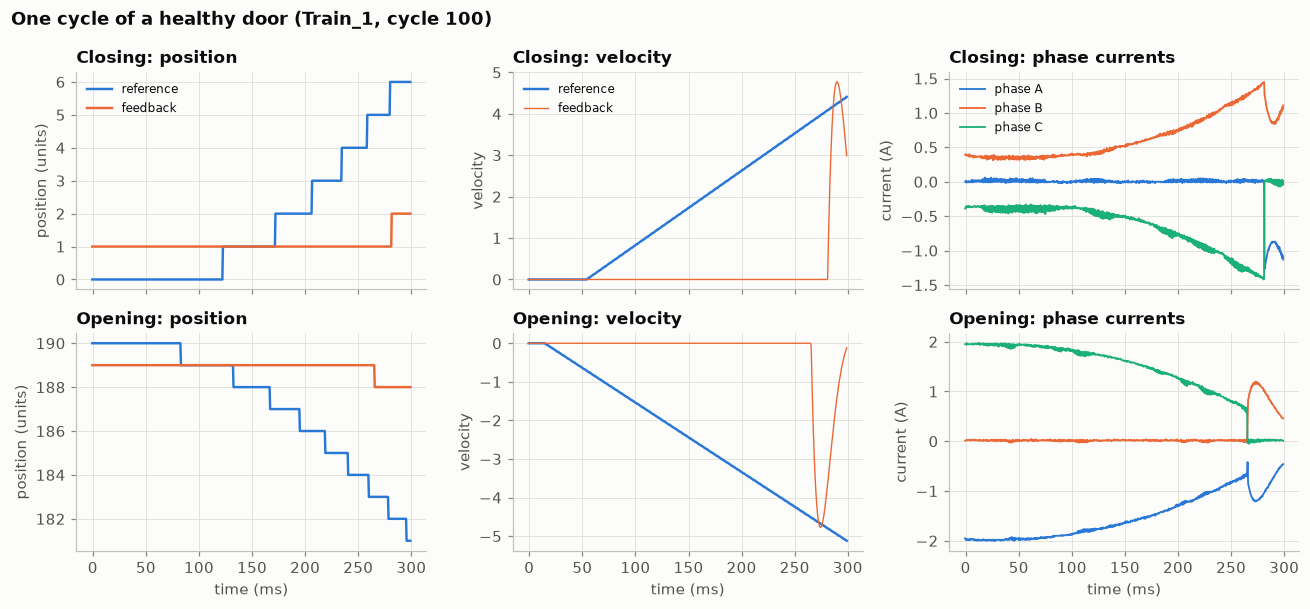

In [4]:
def read_raw(base, run, cycle, kind):
    folder = base / f"{base.name}_{run}"
    return pd.read_csv(next(folder.glob(f"F_*_{cycle:05d}_{kind}.csv")), sep=";", header=None, names=COLS)

fig, axes = plt.subplots(2, 3, figsize=(12, 5.6), sharex=True)
for row, kind in enumerate(["Closing", "Opening"]):
    d = read_raw(TRAIN_DIR, 1, 100, kind); t = d.t * 1000
    ax = axes[row, 0]
    ax.plot(t, d.pos_ref, label="reference"); ax.plot(t, d.pos_fbk, label="feedback")
    ax.set_title(f"{kind}: position"); ax.set_ylabel("position (units)")
    ax = axes[row, 1]
    ax.plot(t, d.vel_ref, label="reference"); ax.plot(t, d.vel_fbk, label="feedback", lw=0.9)
    ax.set_title(f"{kind}: velocity"); ax.set_ylabel("velocity")
    ax = axes[row, 2]
    for c, lab in zip(["cur_a", "cur_b", "cur_c"], ["phase A", "phase B", "phase C"]):
        ax.plot(t, d[c], label=lab, lw=1.2)
    ax.set_title(f"{kind}: phase currents"); ax.set_ylabel("current (A)")
for ax in axes[0]: ax.legend(fontsize=8, loc="upper left")
for ax in axes[1]: ax.set_xlabel("time (ms)")
fig.suptitle("One cycle of a healthy door (Train_1, cycle 100)", x=0.01, ha="left", fontweight="bold")
fig.tight_layout(); fig.savefig(FIG / "01_cycle_anatomy.png"); plt.show()

**Reading the plot**

- The recording stops while the velocity reference is still ramping up. The file never shows the door arriving, so the end-of-travel position is **not** visible in a `Closing` file.
- Position is reported in whole units, and the reference moves only 6 to 9 units inside the window while the feedback barely changes. The waveform itself is too coarse to show subtle wear.
- The `Opening` file starts with the door sitting where the previous closing move left it (190 on a healthy door). **That starting value is the only place where the closing position can be read.**

## 1.3 Operating conditions

The document lists three conditions (velocity / acceleration / deceleration of 15/18/18, 10/15/15 and 15/18/15) and asks for a model that does not know the condition. What can be recovered from the signals?

In [5]:
def closing_accel(base, run):
    """Slope of the velocity reference ramp, median over cycles 5 to 14."""
    out = []
    for c in range(5, 15):
        d = read_raw(base, run, c, "Closing"); v = d.vel_ref.abs().to_numpy(); t = d.t.to_numpy()
        m = (v > 0.5) & (v < 0.9 * v.max())
        out.append(np.polyfit(t[m], v[m], 1)[0])
    return float(np.median(out))

acc_tr = pd.Series({r: closing_accel(TRAIN_DIR, r) for r in sorted(train.run.unique())})
acc_te = pd.Series({r: closing_accel(TEST_DIR, r) for r in sorted(test.run.unique())})
cond_tr = acc_tr.round().map({18.0: "fast", 10.0: "slow"})
cond_te = acc_te.round().map({18.0: "fast", 10.0: "slow"})
train["cond"] = train.run.map(cond_tr); test["cond"] = test.run.map(cond_te)
pd.DataFrame({"closing ramp slope": [18, 10],
              "train runs": [(cond_tr == "fast").sum(), (cond_tr == "slow").sum()],
              "test runs": [(cond_te == "fast").sum(), (cond_te == "slow").sum()]}, index=["fast", "slow"])

,closing ramp slope,train runs,test runs
fast,18,32,12
slow,10,16,7


Only **two** groups are visible: a fast ramp (32 train runs, 12 test) and a slow ramp (16 train, 7 test).
Two of the three documented conditions share velocity and acceleration and differ only in *deceleration*, which happens after the 0.3 s window ends.
I could not separate those two from the reference profile inside the window, so the analysis uses the two observable groups, `fast` and `slow`.

## 1.4 The health indicator

The door's last closing position is read from the `Opening` file. Two versions were compared: the first sample of position feedback, and the maximum over the file.

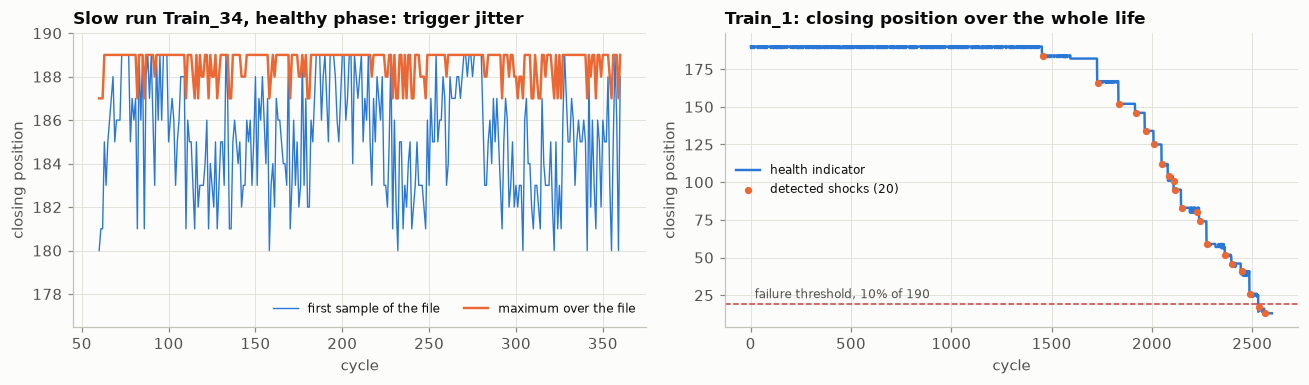

Noise (std) of each candidate over cycles 20 to 200, median across runs:
      first sample  maximum
cond                       
fast           0.0      0.0
slow           1.3      0.0


In [6]:
fig, axes = plt.subplots(1, 2, figsize=(12, 3.6))
d = train[(train.run == 34) & (train.kind == "Opening") & (train.cycle.between(60, 360))]
axes[0].plot(d.cycle, d.pos_fbk_first, lw=0.9, label="first sample of the file")
axes[0].plot(d.cycle, d.pos_fbk_max, lw=1.6, label="maximum over the file")
axes[0].set_title("Slow run Train_34, healthy phase: trigger jitter"); axes[0].set_xlabel("cycle"); axes[0].set_ylabel("closing position")
axes[0].set_ylim(176.5, 190)
axes[0].legend(fontsize=8, loc="lower right", ncol=2)

hi1 = health_series(train[train.run == 1]); sh1 = detect_shocks(hi1)
axes[1].plot(hi1.index, hi1.values, label="health indicator")
axes[1].scatter(sh1.cycle, sh1.after, s=14, color=ps.ORANGE, zorder=3, label=f"detected shocks ({len(sh1)})")
axes[1].axhline(19, color=ps.CRITICAL, lw=1, ls="--"); axes[1].text(20, 23, "failure threshold, 10% of 190", color=ps.INK2, fontsize=8)
axes[1].set_title("Train_1: closing position over the whole life"); axes[1].set_xlabel("cycle"); axes[1].set_ylabel("closing position")
axes[1].legend(fontsize=8, loc="center left")
fig.tight_layout(); fig.savefig(FIG / "02_health_indicator.png"); plt.show()

noise = []
for r, d in train[train.kind == "Opening"].groupby("run"):
    h = d[d.cycle.between(20, 200)]
    noise.append({"cond": cond_tr[r], "first sample": h.pos_fbk_first.std(), "maximum": h.pos_fbk_max.std()})
print("Noise (std) of each candidate over cycles 20 to 200, median across runs:")
print(pd.DataFrame(noise).groupby("cond").median().round(2))

**Findings**

- In slow runs the recording sometimes starts after the door has already begun to move, so the first sample reads several units low. Taking the **maximum** over the file removes that artefact. This is the health indicator used from here on.
- The door does not wear smoothly. It holds a level, then drops in a **step** (a "shock"), holds, and drops again, until the closing position falls to roughly 10% of nominal and the run ends.
- A step detector (`src/health.py`) recovers the shocks. It takes the rolling maximum of the indicator over 5 cycles, then looks for a drop of at least 3 units that holds for 5 cycles.
- **Why the detector is built that way.** A late trigger can only make the indicator read low, and in a few slow runs (for example `Train_34` above, and `Test_14`) even the file maximum flickers 2 units below the true level. A first version of the detector, with a 2-unit threshold and no rolling maximum, reported false "first shocks" in the middle of the plateau of those runs. Real shocks are 3 units or larger and never recover, which is what the current rule relies on. With it, no detected shock in any of the 67 runs is followed by a return to the previous level.

In [7]:
runs = []
shocks = []
for name, df, cond in (("train", train, cond_tr), ("test", test, cond_te)):
    for r, d in df.groupby("run"):
        hi = health_series(d); s = detect_shocks(hi)
        s = s.assign(set=name, run=r, k=np.arange(1, len(s) + 1), cond=cond[r])
        shocks.append(s)
        runs.append({"set": name, "run": r, "cond": cond[r], "life": total_cycles(d),
                     "hi_start": hi.iloc[:20].median(), "hi_end": hi.iloc[-5:].median(), "n_shocks": len(s),
                     "first_shock": s.cycle.iloc[0] if len(s) else np.nan,
                     "last_shock": s.cycle.iloc[-1] if len(s) else np.nan,
                     "gap_early": s.gap.iloc[1:4].mean() if len(s) >= 4 else np.nan,
                     "gap_steady": s.gap.iloc[4:].median() if len(s) >= 6 else np.nan})
runs = pd.DataFrame(runs); shocks = pd.concat(shocks, ignore_index=True)
shocks[["cycle", "before", "after", "pct", "gap"]] = shocks[["cycle", "before", "after", "pct", "gap"]].astype(float)
R = runs[runs.set == "train"].set_index("run"); S = shocks[shocks.set == "train"]
R.describe().round(1)

,life,hi_start,hi_end,n_shocks,first_shock,last_shock,gap_early,gap_steady
count,48.0,48.0,48.0,48.0,48.0,48.0,47.0,47.0
mean,2007.0,188.9,19.1,17.6,916.8,1956.7,94.0,53.7
std,814.1,0.9,23.7,6.0,355.8,794.9,68.2,24.7
min,336.0,188.0,8.0,1.0,224.0,330.0,13.3,13.0
25%,1410.2,188.0,13.0,13.0,637.0,1379.8,58.2,34.2
50%,2081.5,189.0,15.0,17.5,821.5,2015.5,83.7,47.0
75%,2422.2,190.0,17.0,20.2,1258.0,2348.2,119.0,71.0
max,4029.0,190.0,170.0,32.0,1543.0,3943.0,480.7,114.0


## 1.5 How degradation unfolds

All 48 training runs, first against cycle number and then against the fraction of life used.

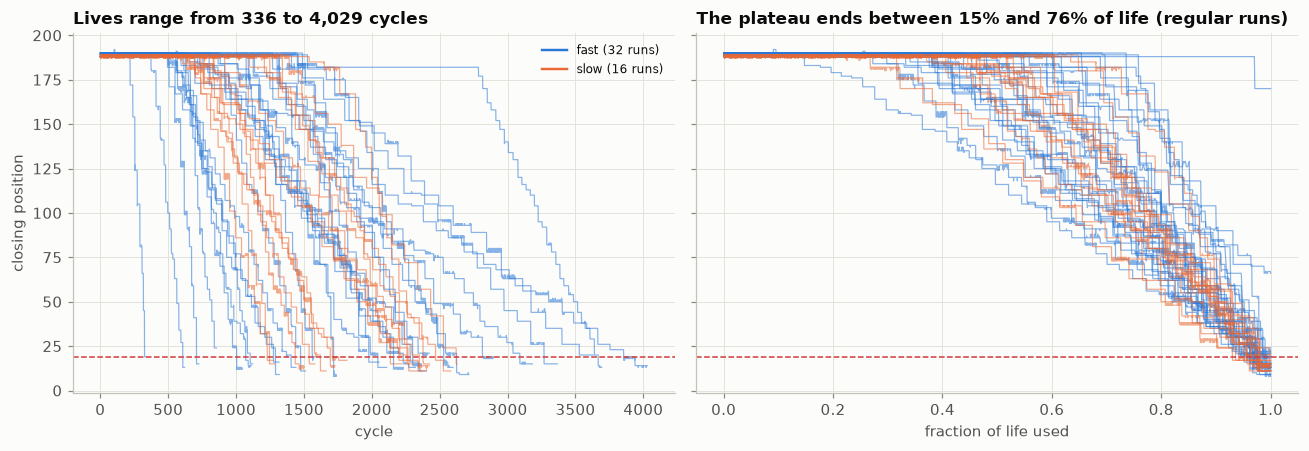

regular runs: 46; first shock at cycle 224 to 1543
first shock arrives at 47% of life on median (range 15% to 76%)
runs that end well above the failure threshold:
     cond  life  hi_end  n_shocks
run                              
5    fast  1876    67.0        23
30   fast  1108   170.0         1


In [8]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4.2), sharey=True)
for r, d in train.groupby("run"):
    hi = health_series(d); col = ps.COND_COLORS[cond_tr[r]]
    axes[0].plot(hi.index, hi.values, color=col, lw=0.8, alpha=0.55)
    axes[1].plot(hi.index / hi.index.max(), hi.values, color=col, lw=0.8, alpha=0.55)
for ax in axes: ax.axhline(19, color=ps.CRITICAL, lw=1, ls="--")
axes[0].plot([], [], color=ps.BLUE, label="fast (32 runs)"); axes[0].plot([], [], color=ps.ORANGE, label="slow (16 runs)")
axes[0].legend(fontsize=8); axes[0].set_xlabel("cycle"); axes[0].set_ylabel("closing position")
axes[0].set_title("Lives range from 336 to 4,029 cycles")
axes[1].set_xlabel("fraction of life used"); axes[1].set_title("The plateau ends between 15% and 76% of life (regular runs)")
fig.tight_layout(); fig.savefig(FIG / "03_all_trajectories.png"); plt.show()

regular = R[R.hi_end <= 30]
frac = (regular.first_shock / regular.life)
print(f"regular runs: {len(regular)}; first shock at cycle {regular.first_shock.min():.0f} to {regular.first_shock.max():.0f}")
print(f"first shock arrives at {frac.median():.0%} of life on median (range {frac.min():.0%} to {frac.max():.0%})")
print("runs that end well above the failure threshold:")
print(R[R.hi_end > 30][["cond", "life", "hi_end", "n_shocks"]])

**Findings**

- Every run has the same shape: a **flat healthy plateau** with no visible trend, then a **staircase** down to failure.
- Lives vary by a factor of twelve, and fast and slow runs overlap completely. The operating condition says little about life.
- The plateau is long and its length varies enormously: in the 46 regular runs the first shock arrives at 47% of life on median, with a range of 15% to 76%. For a large part of most runs the health indicator is simply flat at nominal.
- Two runs are irregular. `Train_30` stops at a closing position of 170 after a single shock, and `Train_5` stops at 67. They did not reach the stated failure threshold, so their "RUL = 1" label marks the end of the recording rather than a failure like the others. They are kept in the tables but flagged, because a model trained on them would learn that doors can fail from near-nominal position.

### Shocks: when, how big, how often

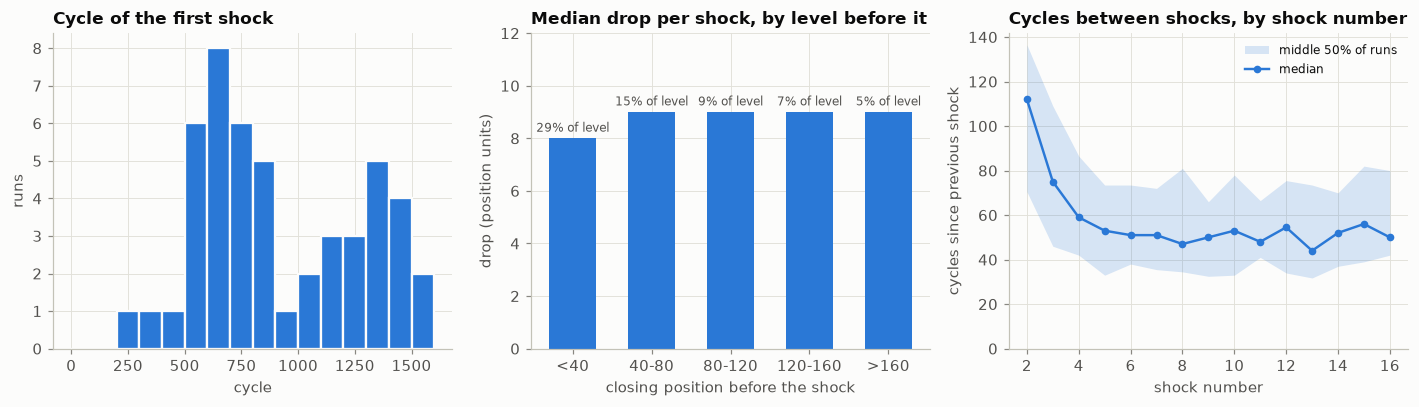

shocks per run: median 17.5 | cycles from last shock to end: median 45.5
median absolute drop: 9.0 units; middle 80% of drops: 4.0 to 15.0
most common drop sizes: {3.0: 79, 6.0: 113, 7.0: 52, 9.0: 116, 12.0: 76, 15.0: 65}
Spearman, drop size vs level before the shock: 0.03


In [9]:
fig, axes = plt.subplots(1, 3, figsize=(13, 3.8))
ax = axes[0]
ax.hist(R.first_shock.dropna(), bins=np.arange(0, 1700, 100), color=ps.BLUE, edgecolor=ps.SURFACE, linewidth=1.5)
ax.set_title("Cycle of the first shock"); ax.set_xlabel("cycle"); ax.set_ylabel("runs")

ax = axes[1]
S2 = S.assign(drop=S.before - S.after)
bins = [0, 40, 80, 120, 160, 200]; labels = ["<40", "40-80", "80-120", "120-160", ">160"]
grp = S2.groupby(pd.cut(S2.before, bins, labels=labels), observed=True)
med_abs, med_pct = grp["drop"].median(), grp["pct"].median()
x = np.arange(len(labels))
ax.bar(x, med_abs.values, width=0.6, color=ps.BLUE)
for xi, (a, p) in enumerate(zip(med_abs.values, med_pct.values)):
    ax.text(xi, a + 0.25, f"{p:.0f}% of level", ha="center", fontsize=8, color=ps.INK2)
ax.set_xticks(x); ax.set_xticklabels(labels); ax.set_ylim(0, 12)
ax.set_title("Median drop per shock, by level before it"); ax.set_xlabel("closing position before the shock"); ax.set_ylabel("drop (position units)")

ax = axes[2]
g = S[(S.k >= 2) & (S.k <= 16)].groupby("k").gap
ax.fill_between(g.median().index, g.quantile(0.25), g.quantile(0.75), color=ps.BLUE, alpha=0.18, linewidth=0, label="middle 50% of runs")
ax.plot(g.median().index, g.median().values, marker="o", ms=4, label="median")
ax.set_ylim(0); ax.set_title("Cycles between shocks, by shock number"); ax.set_xlabel("shock number"); ax.set_ylabel("cycles since previous shock")
ax.legend(fontsize=8)
fig.tight_layout(); fig.savefig(FIG / "04_shock_statistics.png"); plt.show()

print("shocks per run: median", R.n_shocks.median(), "| cycles from last shock to end: median", (R.life - R.last_shock).median())
print("median absolute drop:", S2["drop"].median(), "units; middle 80% of drops:", S2["drop"].quantile(0.1), "to", S2["drop"].quantile(0.9))
print("most common drop sizes:", S2["drop"].round().value_counts().head(6).sort_index().astype(int).to_dict())
print(f"Spearman, drop size vs level before the shock: {spearmanr(S2['drop'], S2.before)[0]:.2f}")

**Findings**

- **The first shock is the big unknown.** In the regular runs it arrives anywhere between cycle 224 and cycle 1,543, with no preferred value.
- **Shock size does not depend on how degraded the door already is.** The median drop is 9 position units at every level (Spearman between drop size and level: 0.03). Individual shocks vary, mostly between 4 and 15 units, with the most common sizes at 3, 6, 9, 12 and 15. As a percentage of the *current* level the shocks therefore grow from 5% to nearly 30%. The challenge document describes a multiplicative rule (each shock removes a percentage of the current position); the data behaves as if the percentage were applied to the *original* position. In practice this means the indicator falls roughly **linearly in the number of shocks**, and a run needs about 18 shocks to go from 190 to the threshold (the median run has 17.5).
- **After the first three or four shocks, the spacing settles.** The early intervals are longer (median 84 cycles over shocks 2 to 4), then the interval levels off (median 47). Within a run the steady interval is typically about two thirds of the early one.

The next plot shows that this steady interval is a property of each run.

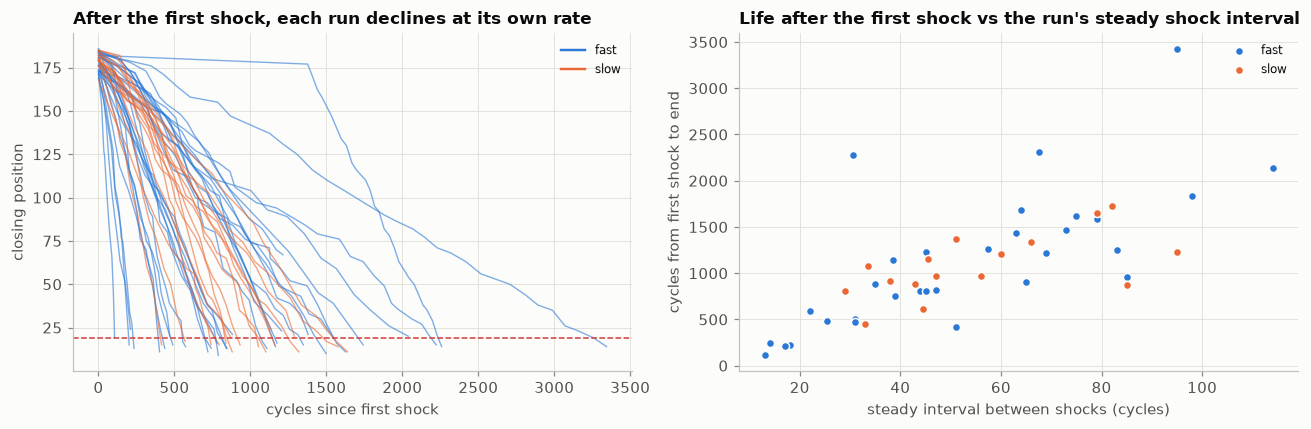

Spearman, life vs cycle of first shock            : 0.71
Spearman, life after first shock vs steady interval: 0.73
Spearman, cycle of first shock vs steady interval  : 0.49
Spearman, early interval (shocks 2-4) vs steady    : 0.69
steady interval ranges from 13 to 114 cycles
steady interval / early interval, median: 0.64


In [10]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
ax = axes[0]
for r, s in S.groupby("run"):
    if len(s) < 6: continue
    ax.plot(s.cycle - s.cycle.iloc[0], s.after, color=ps.COND_COLORS[cond_tr[r]], lw=0.9, alpha=0.6)
ax.axhline(19, color=ps.CRITICAL, lw=1, ls="--")
ax.plot([], [], color=ps.BLUE, label="fast"); ax.plot([], [], color=ps.ORANGE, label="slow"); ax.legend(fontsize=8)
ax.set_title("After the first shock, each run declines at its own rate"); ax.set_xlabel("cycles since first shock"); ax.set_ylabel("closing position")

ax = axes[1]
m = R.dropna(subset=["gap_steady"])
for c in ("fast", "slow"):
    mm = m[m.cond == c]
    ax.scatter(mm.gap_steady, mm.life - mm.first_shock, s=28, color=ps.COND_COLORS[c], edgecolor=ps.SURFACE, linewidth=1, label=c)
ax.set_title("Life after the first shock vs the run's steady shock interval"); ax.set_xlabel("steady interval between shocks (cycles)"); ax.set_ylabel("cycles from first shock to end")
ax.legend(fontsize=8)
fig.tight_layout(); fig.savefig(FIG / "05_run_rate.png"); plt.show()

rho = lambda a, b: spearmanr(a, b, nan_policy="omit")[0]
print(f"Spearman, life vs cycle of first shock            : {rho(R.life, R.first_shock):.2f}")
print(f"Spearman, life after first shock vs steady interval: {rho(m.life - m.first_shock, m.gap_steady):.2f}")
print(f"Spearman, cycle of first shock vs steady interval  : {rho(m.first_shock, m.gap_steady):.2f}")
print(f"Spearman, early interval (shocks 2-4) vs steady    : {rho(m.gap_early, m.gap_steady):.2f}")
print(f"steady interval ranges from {m.gap_steady.min():.0f} to {m.gap_steady.max():.0f} cycles")
print(f"steady interval / early interval, median: {(m.gap_steady / m.gap_early).median():.2f}")

**A run's life is made of three parts**

| Part | What it is | Can it be seen coming? |
|---|---|---|
| Plateau | cycles until the first shock | No. Nothing in the position signal changes beforehand. |
| Transition | first three or four shocks, more widely spaced | Partly. |
| Steady decline | about 14 more shocks at a fixed interval of 13 to 114 cycles, depending on the run | Yes, once a few intervals have been seen. |

The steady interval is strongly tied to how long the run lasts after the first shock (Spearman 0.73). It is also moderately related to when the first shock happened (0.49): runs with a long plateau tend to degrade more slowly afterwards. **So the length of the plateau carries some information about the pace to come, but far less than the first few intervals do.**

## 1.6 Do the other sensors add anything?

Currents, voltages, velocities and temperatures are also recorded. Two separate questions:

1. Within a run, which features move with the health indicator? (They may just be the same information again.)
2. Across runs, does anything measured during the healthy plateau predict the first shock or the later shock rate? This is the valuable case, since the plateau is where position is silent.

In [11]:
feat_cols = [c for c in train.columns if c not in ("run", "cycle", "kind", "rul", "n_rows", "cond")]
rows = []
for r, d in train.groupby("run"):
    if r in (5, 30): continue
    hi = health_series(d)
    for kind in ("Closing", "Opening"):
        k = d[d.kind == kind].set_index("cycle")
        idx = k.index.intersection(hi.index)
        for c in feat_cols:
            x = k.loc[idx, c]
            if x.std() == 0: continue
            rows.append({"run": r, "feature": f"{kind[:2]}_{c}", "rho": spearmanr(x, hi.loc[idx])[0]})
within = pd.DataFrame(rows).groupby("feature").rho.agg(median="median", min_abs=lambda s: s.abs().min(), n="size")
within = within[within.n >= 40].sort_values("median", key=np.abs, ascending=False)
print("Features that track the health indicator within a run (median Spearman over 46 runs):")
within.head(14).round(2)

Features that track the health indicator within a run (median Spearman over 46 runs):


,median,min_abs,n
feature,,,
Op_pos_fbk_max,1.00,1.00,46
Op_pos_fbk_first,1.00,0.89,46
Op_pos_ref_max,1.00,0.86,46
Op_pos_ref_first,1.00,0.86,46
Op_pos_fbk_min,0.99,0.80,46
Op_pos_fbk_last,0.99,0.80,46
Op_pos_fbk_mean,0.96,0.75,46
Op_pos_ref_last,0.95,0.78,46
Op_pos_ref_min,0.95,0.83,46


In [12]:
# Across runs: healthy-plateau averages (cycles 20 to 150, before any training shock except four early ones) vs what happens later
early = train[train.cycle.between(20, 150)]
E = pd.concat([early[early.kind == k].groupby("run")[feat_cols].mean().add_prefix(k[:2] + "_") for k in ("Closing", "Opening")], axis=1)
E = E.loc[:, E.std() > 0].drop(index=[5, 30])
targets = {"first_shock": R.first_shock, "gap_steady": R.gap_steady, "life": R.life}
rng = np.random.default_rng(0)
out = []
for tname, tgt in targets.items():
    y = tgt.reindex(E.index)
    ok = y.notna()
    rhos = E[ok].apply(lambda col: spearmanr(col, y[ok])[0])
    # what the strongest of this many features looks like when the target is shuffled
    null = [E[ok].apply(lambda col: spearmanr(col, rng.permutation(y[ok].to_numpy()))[0]).abs().max() for _ in range(200)]
    out.append({"target": tname, "strongest feature": rhos.abs().idxmax(), "its |rho|": rhos.abs().max(),
                "95% of shuffled maxima are below": np.quantile(null, 0.95), "features tested": len(rhos)})
pd.DataFrame(out).round(2)

,target,strongest feature,its |rho|,95% of shuffled maxima are below,features tested
0,first_shock,Cl_vol_a_mean,0.39,0.53,162
1,gap_steady,Cl_pos_fbk_first,0.43,0.52,162
2,life,Cl_vol_a_last,0.39,0.50,162


**Findings**

- Within a run, the features that follow the health indicator are position summaries, almost all from the `Opening` file. They restate the indicator; they do not lead it.
- Driver temperature also correlates within a run (about -0.7), but that is the electronics warming up as the run goes on. It tracks elapsed time, not damage.
- Across runs, the question is whether the best of 162 plateau-phase features beats what the best of 162 features achieves when the target is shuffled. For all three targets (cycle of the first shock, steady shock interval, total life) the best feature is **below** that noise ceiling. No single sensor feature gives a convincing early warning.
- This is a one-feature-at-a-time test with 46 runs, so it has little power. Notebook 2 repeats the question with a model that can combine features, under cross-validation, and finds a small effect with a different explanation.

This fits how the data was made: the shocks are injected by a script on a random schedule. They are not caused by wear that a current or temperature sensor could pick up early.

## 1.7 Wall-clock time

The files carry no timestamp column, but the test archive preserves each file's original modification time from the 2020 acquisition campaign. That gives the real duration of a cycle.

In [13]:
zpath = ROOT / "phm2026data-test_date" / "Test.zip"
times = {}
with zipfile.ZipFile(zpath) as z:
    for i in z.infolist():
        parts = i.filename.split("/")
        if "__MACOSX" in i.filename or not parts[-1].endswith("ing.csv"): continue
        times.setdefault(int(parts[-2].split("_")[1]), []).append(dt.datetime(*i.date_time))
clock = pd.DataFrame({r: {"start": min(v), "hours": (max(v) - min(v)).total_seconds() / 3600,
                          "sec_per_cycle": (max(v) - min(v)).total_seconds() / (len(v) / 2)} for r, v in times.items()}).T.sort_index()
clock["cond"] = cond_te
print(clock.groupby("cond").sec_per_cycle.agg(["median", "min", "max"]).astype(float).round(2))
spc = float(clock.sec_per_cycle.astype(float).median())
print(f"\nmedian cycle duration: {spc:.2f} s")
print(f"first shock in training runs: median {R.first_shock.median() * spc / 3600:.2f} h, range {R.first_shock.min() * spc / 3600:.2f} to {R.first_shock.max() * spc / 3600:.2f} h")
print(f"share of training runs whose first shock falls inside the documented 1 to 2 hour window: {((R.first_shock * spc).between(3600, 7200)).mean():.0%}")

      median   min   max
cond                    
fast    4.99  4.36  7.59
slow    5.04  4.51  6.20

median cycle duration: 5.04 s
first shock in training runs: median 1.15 h, range 0.31 to 2.16 h
share of training runs whose first shock falls inside the documented 1 to 2 hour window: 52%


**Findings**

- A cycle takes about 5 seconds in both conditions, so cycle count and elapsed time are interchangeable.
- The document says the first shock is drawn from 3,600 to 7,200 seconds. Converted to time, 52% of training runs have their first shock in that window; the others range from 0.3 to 2.2 hours. The documented ranges are an example, not the actual settings of every run.
- A caution for anyone using this dataset: archive timestamps are metadata about how the experiment campaign was scheduled. They are not sensor data and would not exist in deployment. This project uses them only for the unit conversion above and **not** as a model input.

## 1.8 The test set

Test runs are not complete. Each is a run cut off at some point, and the task is to say how much longer it would have lasted.

test runs by stage: {'no shock yet': 6, '3-4 shocks': 5, '1-2 shocks': 4, '5+ shocks': 4} | with four shocks or fewer: 15
     cond  cycles_seen  hi_end  n_shocks  first_shock         stage
run                                                                
1    fast         1797   161.0         3       1582.0    3-4 shocks
2    fast         1179   181.0         1        768.0    1-2 shocks
3    fast          253   190.0         0          NaN  no shock yet
4    fast         1350   188.0         0          NaN  no shock yet
5    fast         3229   113.0        12       1803.0     5+ shocks
6    fast         1133   113.0         7        745.0     5+ shocks
7    fast          568   190.0         0          NaN  no shock yet
8    fast          928   155.0         3        618.0    3-4 shocks
9    fast          889   189.0         0          NaN  no shock yet
10   fast         1692   176.0         3       1354.0    3-4 shocks
11   fast         1766   128.0         5       1065.0     5+ s

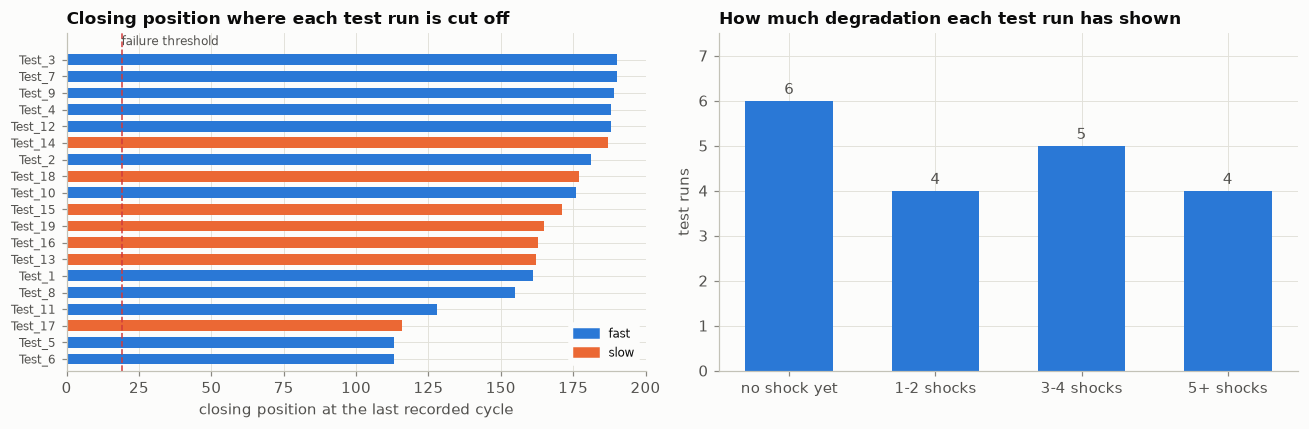

In [14]:
T = runs[runs.set == "test"].set_index("run")
T["cycles_seen"] = test.groupby("run").cycle.max()
T["stage"] = np.select([T.n_shocks == 0, T.n_shocks <= 2, T.n_shocks <= 4], ["no shock yet", "1-2 shocks", "3-4 shocks"], "5+ shocks")
print("test runs by stage:", T.stage.value_counts().to_dict(), "| with four shocks or fewer:", int((T.n_shocks <= 4).sum()))
print(T[["cond", "cycles_seen", "hi_end", "n_shocks", "first_shock", "stage"]].to_string())

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
ax = axes[0]
order = T.sort_values("hi_end").index
ax.barh([f"Test_{r}" for r in order], T.loc[order, "hi_end"], color=[ps.COND_COLORS[c] for c in T.loc[order, "cond"]], height=0.65)
ax.axvline(19, color=ps.CRITICAL, lw=1, ls="--"); ax.text(19, len(order) - 0.3, "failure threshold", color=ps.INK2, fontsize=8, va="bottom", ha="left")
ax.set_ylim(-0.7, len(order) + 0.6)
ax.legend(handles=[Patch(color=ps.BLUE, label="fast"), Patch(color=ps.ORANGE, label="slow")], fontsize=8, loc="lower right", facecolor=ps.SURFACE, framealpha=1, frameon=True, edgecolor=ps.SURFACE)
ax.set_xlim(0, 200); ax.set_title("Closing position where each test run is cut off"); ax.set_xlabel("closing position at the last recorded cycle")
ax.tick_params(axis="y", labelsize=8)

ax = axes[1]
stage_order = ["no shock yet", "1-2 shocks", "3-4 shocks", "5+ shocks"]
cnt = T.stage.value_counts().reindex(stage_order).fillna(0)
ax.bar(stage_order, cnt.values, width=0.6, color=ps.BLUE)
for i, v in enumerate(cnt.values): ax.text(i, v + 0.15, int(v), ha="center", color=ps.INK2)
ax.set_title("How much degradation each test run has shown"); ax.set_ylabel("test runs"); ax.set_ylim(0, cnt.max() + 1.5)
fig.tight_layout(); fig.savefig(FIG / "06_test_truncation.png"); plt.show()

**Findings**

- No test run is anywhere near failure. The most degraded ones are cut off at a closing position of about 113, with more than half of the staircase still to come.
- Six test runs are cut off **before any shock** and four more after only one or two. For those ten runs the steady shock interval, the one thing that predicts remaining life well, has not been observed. Only four runs have five or more shocks.
- So the test set sits mostly in the hard part of the problem identified above.

## 1.9 How predictable is life at each stage?

Using the training runs, the table below asks: standing at a given point in a run, how spread out is the remaining life? No model is involved. It measures the uncertainty that any model has to live with.

In [15]:
good = R.drop(index=[5, 30])
rows = []
# before any shock: remaining life of runs still on the plateau at cycle t
for t in (250, 500, 750, 1000):
    alive = good[good.first_shock > t]
    rem = alive.life - t
    rows.append({"standing at": f"cycle {t}, no shock yet", "runs": len(alive), "median remaining": rem.median(),
                 "p10": rem.quantile(0.1), "p90": rem.quantile(0.9)})
for k in (1, 2, 3, 5, 8):
    sk = S[(S.k == k) & S.run.isin(good.index)].set_index("run")
    rem = good.life.reindex(sk.index) - sk.cycle
    rows.append({"standing at": f"shock {k}", "runs": len(sk), "median remaining": rem.median(),
                 "p10": rem.quantile(0.1), "p90": rem.quantile(0.9)})
spread = pd.DataFrame(rows)
spread["p90 / p10"] = spread.p90 / spread.p10
spread.round(1)

,standing at,runs,median remaining,p10,p90,p90 / p10
0,"cycle 250, no shock yet",45,1947.0,866.4,2817.4,3.3
1,"cycle 500, no shock yet",43,1719.0,653.6,2625.2,4.0
2,"cycle 750, no shock yet",26,1633.0,909.5,2524.5,2.8
3,"cycle 1000, no shock yet",18,1424.5,997.1,2445.5,2.5
4,shock 1,46,971.5,431.0,1781.0,4.1
5,shock 2,46,867.0,376.0,1567.5,4.2
6,shock 3,46,791.5,337.5,1454.5,4.3
7,shock 5,46,681.5,254.0,1284.0,5.1
8,shock 8,46,504.5,141.0,1041.5,7.4


In [16]:
# The same question with the simplest possible use of the shock rate:
# remaining = (shocks still needed) x (mean interval seen so far), from shock 3 onwards
rows = []
for k in (3, 4, 5, 6, 8, 10):
    errs = []
    for r, s in S[S.run.isin(good.index)].groupby("run"):
        if len(s) < k: continue
        seen = s.iloc[:k]
        interval = seen.gap.iloc[1:].mean()
        needed = max((seen.after.iloc[-1] - 19) / 9.0, 0)
        pred = seen.cycle.iloc[-1] + needed * interval
        errs.append((pred - good.life[r]) / good.life[r])
    errs = np.array(errs)
    rows.append({"shocks seen": k, "runs": len(errs), "median error in predicted life": np.median(errs),
                 "median absolute error": np.median(np.abs(errs)), "within 10%": np.mean(np.abs(errs) <= 0.10)})
pd.DataFrame(rows).round(3)

,shocks seen,runs,median error in predicted life,median absolute error,within 10%
0,3,46,0.256,0.256,0.087
1,4,46,0.185,0.185,0.152
2,5,46,0.148,0.158,0.370
3,6,46,0.098,0.111,0.478
4,8,46,0.045,0.065,0.761
5,10,44,0.023,0.047,0.818


**Findings**

- **Knowing only the stage is not enough.** Whether a run is on the plateau or has had eight shocks, the 90th percentile of remaining life is 3 to 7 times the 10th. The stage alone never pins life down.
- **Knowing the run's own shock rate is what helps.** A back-of-envelope extrapolation (shocks still needed times the mean interval seen so far) has a median error in total life of 26% after three shocks, 10% after six and about 5% after ten.
- That extrapolation is biased long at first, because the early intervals are wider than the steady ones. This is the transition effect from section 1.5, and correcting it is an obvious job for a model.
- Fifteen of the 19 test runs have four shocks or fewer, which is the regime where even the informed estimate is off by 20% or more.

## 1.10 What the scoring metric rewards

The official score averages three parts per test run: an RMSE term, the share of files within 10% relative error, and a "prognostic horizon" (weight 2 of 4) that stops counting at the **first** file whose relative error exceeds 20%.
Because true RUL is a countdown, a prediction is fully described by one number: the error in the predicted run length. The plot shows the score as that error varies, for a typical test situation.

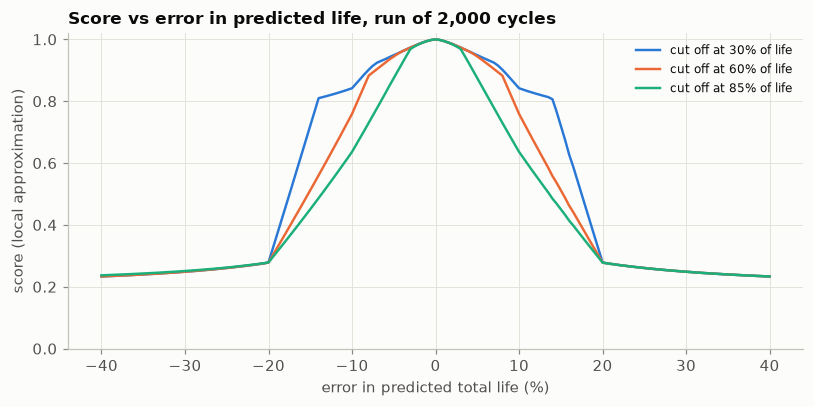

In [17]:
def score_for_error(life, seen, err_frac):
    n_files = 2 * seen
    i = np.arange(n_files)
    true = np.ceil((2 * life - i) / 2)
    pred = np.maximum(np.ceil((2 * life * (1 + err_frac) - i) / 2), 1)
    return score_run(true, pred)

errs = np.linspace(-0.4, 0.4, 161)
fig, ax = plt.subplots(figsize=(7.5, 3.8))
for (life, seen), col in zip([(2000, 600), (2000, 1200), (2000, 1700)], [ps.BLUE, ps.ORANGE, ps.AQUA]):
    ax.plot(errs * 100, [score_for_error(life, seen, e)["score"] for e in errs], color=col, label=f"cut off at {seen / life:.0%} of life")
ax.set_xlabel("error in predicted total life (%)"); ax.set_ylabel("score (local approximation)"); ax.set_ylim(0, 1.02)
ax.set_title("Score vs error in predicted life, run of 2,000 cycles"); ax.legend(fontsize=8)
fig.tight_layout(); fig.savefig(FIG / "07_metric_sensitivity.png"); plt.show()

**Findings**

- **There is a cliff at 20%.** The first file of a run has the largest true RUL, the full life. If the predicted life is more than 20% off, the very first file is already outside the band, the horizon term is zero, and the score collapses to about 0.25 however good the rest is.
- Inside the band the score still falls quickly, and faster for runs cut off late in life, because their remaining life is small and the same absolute error is a larger share of it.
- Caveat: the document leaves two details of the formula open (how the precision percentage is normalised and the direction of the horizon ratio). `src/scoring.py` states the reading used here. Local scores are for comparing models with each other, not for predicting the leaderboard number.

## 1.11 Summary

**What the data is**

- 48 complete training runs and 19 truncated test runs, structurally clean, with one packaging leftover and two training runs that end without reaching the failure threshold.
- RUL is a countdown, so the whole task reduces to predicting one number per run: its total length.

**How the door fails**

- One signal carries the degradation: the closing position, read from the start of each `Opening` file.
- It is flat for a long and highly variable plateau, then falls in steps averaging 9 units, whatever the current level. After three or four steps the interval between steps is constant within a run and differs between runs by a factor of nine.
- Other sensors mirror position, and no single sensor feature shows a convincing early warning during the plateau, which is consistent with the shocks being injected on a random schedule.

**The problem to solve**

- Remaining life can be estimated to within about 5% once ten shocks have been seen, to about 25% after three, and is close to unknowable before the first one.
- Fifteen of the 19 test runs are cut off with four shocks or fewer, six of them with none.
- The metric has a cliff at 20% error in total life, which is the typical error in exactly the regime where the test set sits.

The leaderboard shows the same picture from the outside: most teams score between 0.4 and 0.8, and three teams sit at 0.996 or above. A near-perfect score would require knowing the length of runs that have not started degrading, which the sensor data in this analysis does not support. That gap is treated here as a reason for caution about what the leaderboard measures, not as a target.

**Plan for modelling (notebook 2)**

1. Build training examples by cutting the 48 complete runs at many points, matched to where test runs are cut.
2. Baselines first: the median life, and the physical extrapolation from section 1.9.
3. A staged model that uses the plateau prior before the first shock and the shock rate after it, compared against a gradient-boosted model on the same features.
4. Validate by leaving whole runs out, never by splitting files of one run across train and validation.
5. Report honest uncertainty: prediction intervals by stage, and where the model cannot do better than the prior.